#Basic codes

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
import cv2
from scipy import signal
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree

Mounted at /content/drive


In [5]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [6]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [7]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/0/"
subhalo = get(sub_url)


#New codes

In [10]:
sub_path = '/content/drive/MyDrive/sub'

all_bhmdot = []
all_sfr = []

for folder_num in range(100):
    save_file_path = os.path.join(sub_path, f'sb{folder_num}.npz')

    if os.path.exists(save_file_path):
        loaded_data = np.load(save_file_path)
        all_bhmdot.append(loaded_data['bhmdot'])
        all_sfr.append(loaded_data['sfr'])
    else:
        print(f"File not found {folder_num}: {save_file_path}")

if all_bhmdot and all_sfr:
    final_bhmdot = np.concatenate(all_bhmdot)
    final_sfr = np.concatenate(all_sfr)

    print(f"Loaded the data from {len(all_bhmdot)} files.")

    print(f"First 10 elements of final_bhmdot: {final_bhmdot[:10]}")

    print(f"First 10 elements of final_sfr: {final_sfr[:10]}")
else:
    print("No data files were found or loaded.")

Loaded the data from 100 files.
First 10 elements of final_bhmdot: [0.00351652 0.0166792  0.00102882 0.00874955 0.00163583 0.00256499
 0.00037256 0.00249654 0.00077815 0.00277787]
First 10 elements of final_sfr: [410.991     61.4731    19.4075    18.2909     6.63607    7.76953
   0.433356   4.90325    4.00612    1.93112 ]


In [42]:
bhl = final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)].tolist()
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-10, 3, 200)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])


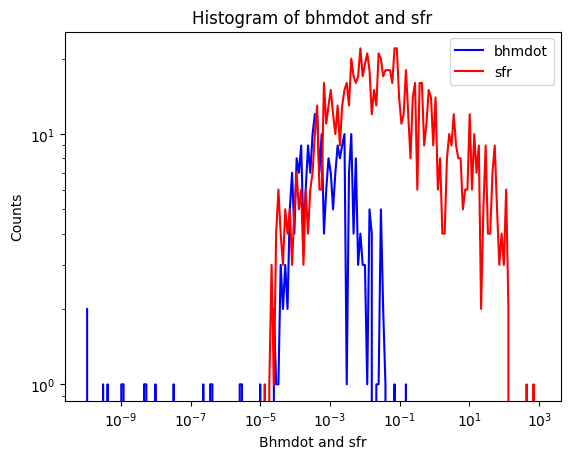

In [43]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()

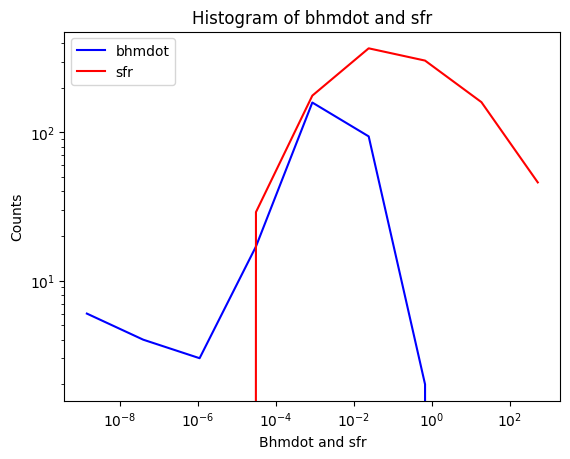

In [45]:
bhl = final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)].tolist()
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-10, 3, 10)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()